# Single Seed Descent Tutorial - Python Version

This notebook replicates the AlphaSimR **Single Seed Descent (SSD)** line-breeding tutorial using **AlphaSimPy**.
It demonstrates a phenotypic line-breeding program with repeated selfing and single‑seed descent, followed by multi‑stage yield trials.

**Scenario**: `LinePheno_SSD` (phenotypic selection with SSD)

**Based on R tutorial files**:
- `GlobalParameters.R`
- `CreateParents.R`
- `FillPipeline.R`
- `AdvanceYear.R`
- `ANALYZERESULTS.R`

**Authors**: Translated from AlphaSimR tutorial by Jon Bancic, Philip Greenspoon, Chris Gaynor, Gregor Gorjanc  
**Python translation**: AlphaSimPy project  
**Package**: AlphaSimPy


## Import Required Libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from AlphaSimPy import (
    runMacs,
    SimParam,
    newPop,
    randCross,
    setPheno,
    selectInd,
    selectWithinFam,
    self,
    meanG,
    varG,
)

print("AlphaSimPy Single Seed Descent (SSD) Tutorial")
print("All libraries imported successfully!")


AlphaSimPy Single Seed Descent (SSD) Tutorial
All libraries imported successfully!


## Global Parameters

Set up the simulation parameters for the SSD line‑breeding program.

This closely follows `GlobalParameters.R` in the R tutorial, with slightly
reduced sizes so the notebook runs quickly in typical environments.


In [8]:
# ---- Number of simulation replications and breeding cycles ----
n_reps = 1        # Number of simulation replicates
n_burnin = 20     # Years in burn‑in phase
n_future = 20     # Years in future phase
n_cycles = n_burnin + n_future

# ---- Genome simulation ----
n_chr = 1         # Number of chromosomes (fixed to 1 for this demo)
n_qtl = 1000      # Number of QTL per chromosome
n_snp = 0         # Number of SNP per chromosome (not used here)

# ---- Initial parents mean and variance ----
init_mean_g = 1.0
init_var_g = 1.0
init_var_env = 1e-6   # Virtually zero for consistency with the R tutorial
init_var_ge = 2.0
var_e = 4.0           # Yield‑trial error variance (per entry mean)

# ---- Breeding program details ----
n_parents = 50   # Number of parents to start each breeding cycle
n_crosses = 100  # Crosses per year
n_progeny = 10   # Selfed progeny produced per cross in S0
fam_max = 10     # Max number of selfed lines per cross to enter PYT
n_pyt = 500      # Entries in Preliminary Yield Trial (PYT)
n_ayt = 50       # Entries in Advanced Yield Trial (AYT)
n_eyt = 10       # Entries in Elite Yield Trial (EYT)

# Effective replication of yield trials (controls h2 by stage)
rep_hdrw = 4.0 / 9.0  # Heritability ~0.1
rep_pyt = 1.0         # Heritability ~0.2
rep_ayt = 4.0         # Heritability ~0.5
rep_eyt = 8.0         # Heritability ~0.7

scenario_name = "LinePheno_SSD"

print("Simulation Parameters")
print(f"  Replicates: {n_reps}")
print(f"  Burn‑in years: {n_burnin}")
print(f"  Future years: {n_future}")
print(f"  Total cycles: {n_cycles}")
print(f"  Chromosomes: {n_chr}")
print(f"  QTL per chromosome: {n_qtl}")
print(f"  Parents per cycle: {n_parents}")
print(f"  Crosses per year: {n_crosses}")
print(f"  Selfed progeny per cross (S0): {n_progeny}")
print(f"  famMax (max lines per family into PYT): {fam_max}")
print(f"  PYT / AYT / EYT sizes: {n_pyt} / {n_ayt} / {n_eyt}")


Simulation Parameters
  Replicates: 1
  Burn‑in years: 20
  Future years: 20
  Total cycles: 40
  Chromosomes: 1
  QTL per chromosome: 1000
  Parents per cycle: 50
  Crosses per year: 100
  Selfed progeny per cross (S0): 10
  famMax (max lines per family into PYT): 10
  PYT / AYT / EYT sizes: 500 / 50 / 10


## Create Founders and Initial Parents

This block mirrors `CreateParents.R`:

1. Simulate founder haplotypes with `runMacs`.
2. Create `SimParam` and define the trait architecture using `addTraitAG`.
3. Enable pedigree tracking (for inbreeding / line tracing).
4. Create the initial parent population and set phenotypes at the EYT level.


In [9]:
print("Creating founders and initial parents...")

# 1. Generate initial haplotypes
founder_pop = runMacs(
    nInd=n_parents,
    nChr=n_chr,
    segSites=n_qtl + n_snp,
    inbred=True,
    species="WHEAT",
)

print(f"✓ Created founder population: {founder_pop.n_ind} individuals, {founder_pop.n_loci[0]} loci")

# 2. Set up simulation parameters
SP = SimParam(founder_pop)

# Trait architecture matching the R tutorial conceptually
SP.addTraitAG(
    nQtlPerChr=n_qtl,
    mean=init_mean_g,
    var=init_var_g,
)

SP.setTrackPed(True)

print(f"✓ Created SimParam with {SP.n_chr} chromosome(s) and {SP.n_traits} trait(s)")

# 3. Create founder parents as a Pop
Parents = newPop(founder_pop, sim_param=SP)

# 4. Add phenotype reflecting evaluation in the Elite Yield Trial (EYT)
Parents = setPheno(Parents, varE=var_e, reps=rep_eyt, simParam=SP)

print(f"✓ Created founder parents: {Parents.n_ind} individuals, {Parents.n_traits} trait(s)")
print(f"  Mean genetic value (Parents): {meanG(Parents)[0]:.3f}")
print(f"  Genetic variance (Parents): {varG(Parents)[0]:.3f}")


Creating founders and initial parents...
50 8E8 -t 4E-7 -r 3.6E-7 -eN 0.03 1 -eN 0.05 2 -eN 0.10 4 -eN 0.15 6 -eN 0.20 8 -eN 0.25 10 -eN 0.30 12 -eN 0.35 14 -eN 0.40 16 -eN 0.45 18 -eN 0.50 20 -eN 1.00 40 -eN 2.00 60 -eN 3.00 80 -eN 4.00 100 -eN 5.00 120 -eN 10.00 140 -eN 20.00 160 -eN 30.00 180 -eN 40.00 200 -eN 50.00 240 -eN 100.00 320 -eN 200.00 400 -eN 300.00 480 -eN 400.00 560 -eN 500.00 640 -s 
✓ Created founder population: 50 individuals, 1000 loci
✓ Created SimParam with 1 chromosome(s) and 1 trait(s)
✓ Created founder parents: 50 individuals, 1 trait(s)
  Mean genetic value (Parents): 1.000
  Genetic variance (Parents): 1.000


## Fill Breeding Pipeline (Burn‑in Setup)

Now we approximate `FillPipeline.R` for the SSD scenario:

Pipeline stages (cohort indexing as in the R code):

1. `F1`   – random crosses from `Parents`
2. `S0`   – selfed progeny from F1 (nProgeny per cross)
3. `S1`   – single‑seed descent from S0
4. `S2`   – single‑seed descent from S1
5. `S3`   – single‑seed descent from S2
6. `S4`   – single‑seed descent from S3 (nearly fully inbred lines)
7. `HDRW` – head‑row yield trial, set phenotypes with `rep_hdrw`
8. `PYT`  – select within family (max `famMax` per family), then mass‑select to `n_pyt`, set phenotypes
9. `AYT`  – select `n_ayt` from PYT, set phenotypes
10. `EYT` – select `n_eyt` from AYT, set phenotypes
11. Variety release (not explicitly modelled here)


In [12]:
print("Filling pipeline (burn‑in setup)...")

# Initialize objects so they are defined before the loop
F1 = None
S0 = None
S1 = None
S2 = None
S3 = None
S4 = None
HDRW = None
PYT = None
AYT = None
EYT = None

for cohort in range(1, 12):  # 1..11 inclusive
    print(f"  FillPipeline stage: {cohort} of 11")

    if cohort < 11:
        # Stage 1: create F1 by random crossing of Parents
        F1 = randCross(Parents, n_crosses, simParam=SP)
        print(f"    ✓ Created F1: {F1.n_ind} individuals from {n_crosses} crosses")

    if cohort < 10:
        # Stage 2: create S0 by selfing F1 (segregating population)
        S0 = self(F1, nProgeny=n_progeny, simParam=SP)
        print(f"    ✓ Created S0: {S0.n_ind} selfed progeny")

    if cohort < 9:
        # Stage 3: single‑seed descent to S1
        S1 = self(S0, simParam=SP)
        print(f"    ✓ Created S1: {S1.n_ind} lines")

    if cohort < 8:
        # Stage 4: single‑seed descent to S2
        S2 = self(S1, simParam=SP)
        print(f"    ✓ Created S2: {S2.n_ind} lines")

    if cohort < 7:
        # Stage 5: single‑seed descent to S3
        S3 = self(S2, simParam=SP)
        print(f"    ✓ Created S3: {S3.n_ind} lines")

    if cohort < 6:
        # Stage 6: single‑seed descent to S4 (nearly fully inbred)
        S4 = self(S3, simParam=SP)
        print(f"    ✓ Created S4: {S4.n_ind} lines")

    if cohort < 5:
        # Stage 7: HDRW – head‑row yield trial
        HDRW = setPheno(S4, varE=var_e, reps=rep_hdrw, simParam=SP)
        print(f"    ✓ HDRW head‑row trial set: {HDRW.n_ind} entries")

    if cohort < 4:
        # Stage 8: PYT – within‑family and among‑family selection
        PYT = selectWithinFam(HDRW, fam_max, simParam=SP)
        PYT = selectInd(PYT, n_pyt, simParam=SP)
        PYT = setPheno(PYT, varE=var_e, reps=rep_pyt, simParam=SP)
        print(f"    ✓ PYT created: {PYT.n_ind} entries")

    if cohort < 3:
        # Stage 9: AYT
        AYT = selectInd(PYT, n_ayt, simParam=SP)
        AYT = setPheno(AYT, varE=var_e, reps=rep_ayt, simParam=SP)
        print(f"    ✓ AYT created: {AYT.n_ind} entries")

    if cohort < 2:
        # Stage 10: EYT
        EYT = selectInd(AYT, n_eyt, simParam=SP)
        EYT = setPheno(EYT, varE=var_e, reps=rep_eyt, simParam=SP)
        print(f"    ✓ EYT created: {EYT.n_ind} entries")

print("\nPipeline filled successfully (end of burn‑in setup).")
print(f"  Final S4 lines: {S4.n_ind if S4 is not None else 0}")
print(f"  Final HDRW entries: {HDRW.n_ind if HDRW is not None else 0}")
print(
    f"  Final PYT / AYT / EYT sizes: "
    f"{PYT.n_ind if PYT is not None else 0} / "
    f"{AYT.n_ind if AYT is not None else 0} / "
    f"{EYT.n_ind if EYT is not None else 0}"
)


Filling pipeline (burn‑in setup)...
  FillPipeline stage: 1 of 11
    ✓ Created F1: 100 individuals from 100 crosses
    ✓ Created S0: 1000 selfed progeny
    ✓ Created S1: 1000 lines
    ✓ Created S2: 1000 lines
    ✓ Created S3: 1000 lines
    ✓ Created S4: 1000 lines
    ✓ HDRW head‑row trial set: 1000 entries
    ✓ PYT created: 500 entries
    ✓ AYT created: 50 entries
    ✓ EYT created: 10 entries
  FillPipeline stage: 2 of 11
    ✓ Created F1: 100 individuals from 100 crosses
    ✓ Created S0: 1000 selfed progeny
    ✓ Created S1: 1000 lines
    ✓ Created S2: 1000 lines
    ✓ Created S3: 1000 lines
    ✓ Created S4: 1000 lines
    ✓ HDRW head‑row trial set: 1000 entries
    ✓ PYT created: 500 entries
    ✓ AYT created: 50 entries
  FillPipeline stage: 3 of 11
    ✓ Created F1: 100 individuals from 100 crosses
    ✓ Created S0: 1000 selfed progeny
    ✓ Created S1: 1000 lines
    ✓ Created S2: 1000 lines
    ✓ Created S3: 1000 lines
    ✓ Created S4: 1000 lines
    ✓ HDRW head‑row

## Run Burn‑in and Future Cycles

This is a simplified analogue of `00RUNME.R` and `AdvanceYear.R`:

- We track:
  - Mean genetic value of S4 (`meanG`)
  - Genetic variance of S4 (`varG`)
  - Selection accuracy in HDRW (`accSel = cor(gv, pheno)`)

The original R code loops over multiple reps; here we show one rep for clarity.


In [13]:
years = np.arange(1, n_cycles + 1)
mean_g = np.zeros(n_cycles)
var_g = np.zeros(n_cycles)
acc_sel = np.zeros(n_cycles)

print("Running burn‑in and future years...")

for year in range(1, n_cycles + 1):
    print(f"  Year {year} of {n_cycles}")

    # --- Stage 11: (variety release not explicitly modeled) ---

    # --- Stage 10: EYT ---
    EYT = selectInd(AYT, n_eyt, simParam=SP)
    EYT = setPheno(EYT, varE=var_e, reps=rep_eyt, simParam=SP)

    # --- Stage 9: AYT ---
    AYT = selectInd(PYT, n_ayt, simParam=SP)
    AYT = setPheno(AYT, varE=var_e, reps=rep_ayt, simParam=SP)

    # --- Stage 8: PYT and selection accuracy in HDRW ---
    hdrw_gv = HDRW.gv[:, 0]
    hdrw_ph = HDRW.pheno[:, 0]
    acc_sel[year - 1] = np.corrcoef(hdrw_gv, hdrw_ph)[0, 1]

    PYT = selectWithinFam(HDRW, fam_max, simParam=SP)
    PYT = selectInd(PYT, n_pyt, simParam=SP)
    PYT = setPheno(PYT, varE=var_e, reps=rep_pyt, simParam=SP)

    # --- Stage 7: HDRW from S4 ---
    HDRW = setPheno(S4, varE=var_e, reps=rep_hdrw, simParam=SP)

    # --- Stage 6: S4 from S3 ---
    S4 = self(S3, simParam=SP)

    # --- Stage 5: S3 from S2 ---
    S3 = self(S2, simParam=SP)

    # --- Stage 4: S2 from S1 ---
    S2 = self(S1, simParam=SP)

    # --- Stage 3: S1 from S0 ---
    S1 = self(S0, simParam=SP)

    # --- Stage 2: S0 from F1 (segregating generation) ---
    S0 = self(F1, nProgeny=n_progeny, simParam=SP)

    # --- Stage 1: F1 from Parents ---
    F1 = randCross(Parents, n_crosses, simParam=SP)

    # Record mean and variance in S4
    mean_g[year - 1] = meanG(S4)[0]
    var_g[year - 1] = varG(S4)[0]

    # --- Update parents (equivalent of UpdateParents.R) ---
    # Replace the 10 oldest parents with the 10 EYT lines
    n_keep = Parents.n_ind - n_eyt
    keep_idx = list(range(n_eyt, Parents.n_ind))  # keep parents 11:nParents

    new_geno = []
    for chr_idx in range(Parents.n_chr):
        p_chr = Parents.geno[chr_idx]
        e_chr = EYT.geno[chr_idx]
        new_chr = np.concatenate(
            [p_chr[:, :, keep_idx], e_chr[:, :, :n_eyt]], axis=2
        )
        new_geno.append(new_chr)

    # Handle EBV matrices that may have 0 columns
    if Parents.ebv.size:
        parents_ebv_keep = Parents.ebv[keep_idx, :]
    else:
        parents_ebv_keep = np.empty((0, 0))
    if EYT.ebv.size:
        eyt_ebv_take = EYT.ebv[:n_eyt, :]
    else:
        eyt_ebv_take = np.empty((0, 0))

    if parents_ebv_keep.size or eyt_ebv_take.size:
        new_ebv = np.vstack([
            parents_ebv_keep,
            eyt_ebv_take,
        ])
    else:
        # No EBV columns: keep an empty matrix with n_ind rows
        new_ebv = np.empty((Parents.n_ind, 0))

    Parents = type(Parents)(
        n_ind=Parents.n_ind,
        n_chr=Parents.n_chr,
        ploidy=Parents.ploidy,
        n_loci=Parents.n_loci,
        geno=new_geno,
        gen_map=Parents.gen_map,
        centromere=Parents.centromere,
        inbred=Parents.inbred,
        id=[Parents.id[i] for i in keep_idx] + [EYT.id[i] for i in range(n_eyt)],
        iid=[Parents.iid[i] for i in keep_idx] + [EYT.iid[i] for i in range(n_eyt)],
        mother=[Parents.mother[i] for i in keep_idx] + [EYT.mother[i] for i in range(n_eyt)],
        father=[Parents.father[i] for i in keep_idx] + [EYT.father[i] for i in range(n_eyt)],
        sex=[Parents.sex[i] for i in keep_idx] + [EYT.sex[i] for i in range(n_eyt)],
        n_traits=Parents.n_traits,
        gv=np.vstack([
            Parents.gv[keep_idx, :],
            EYT.gv[:n_eyt, :],
        ]),
        pheno=np.vstack([
            Parents.pheno[keep_idx, :],
            EYT.pheno[:n_eyt, :],
        ]),
        ebv=new_ebv,
        gxe=Parents.gxe,
        fix_eff=[Parents.fix_eff[i] for i in keep_idx] + [EYT.fix_eff[i] for i in range(n_eyt)],
        misc=Parents.misc,
        misc_pop=Parents.misc_pop,
    )

print("Simulation years complete.")


Running burn‑in and future years...
  Year 1 of 40
  Year 2 of 40
  Year 3 of 40
  Year 4 of 40
  Year 5 of 40
  Year 6 of 40
  Year 7 of 40
  Year 8 of 40
  Year 9 of 40
  Year 10 of 40
  Year 11 of 40
  Year 12 of 40
  Year 13 of 40
  Year 14 of 40
  Year 15 of 40
  Year 16 of 40
  Year 17 of 40
  Year 18 of 40
  Year 19 of 40
  Year 20 of 40
  Year 21 of 40
  Year 22 of 40
  Year 23 of 40
  Year 24 of 40
  Year 25 of 40
  Year 26 of 40
  Year 27 of 40
  Year 28 of 40
  Year 29 of 40
  Year 30 of 40
  Year 31 of 40
  Year 32 of 40
  Year 33 of 40
  Year 34 of 40
  Year 35 of 40
  Year 36 of 40
  Year 37 of 40
  Year 38 of 40
  Year 39 of 40
  Year 40 of 40
Simulation years complete.


## Plot Genetic Gain, Genetic Variance, and Selection Accuracy

This corresponds to `ANALYZERESULTS.R` in the R tutorial,
but implemented with `matplotlib` for this single‑rep example.


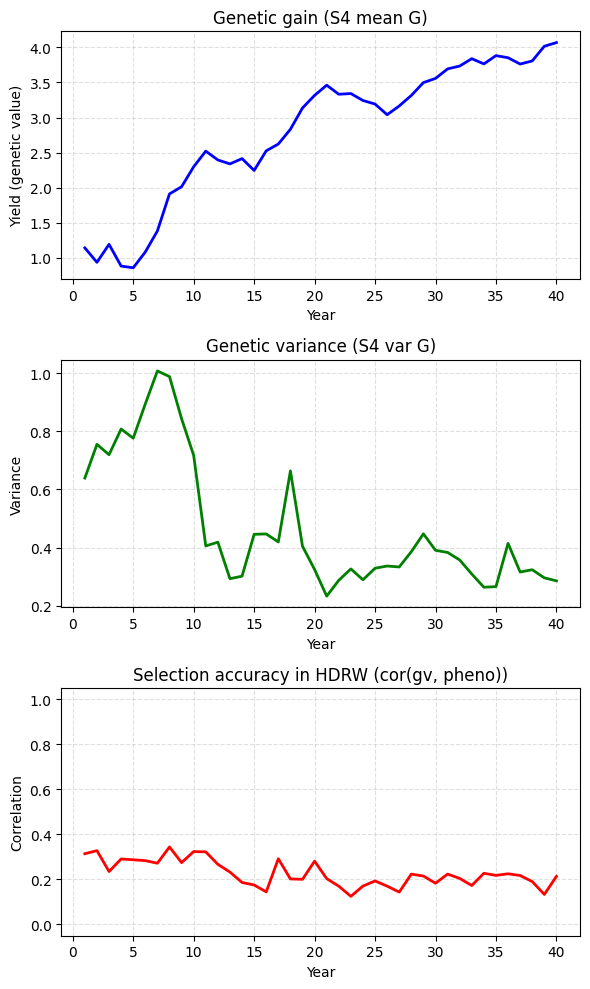

In [14]:
plt.figure(figsize=(6, 10))

# Genetic gain
plt.subplot(3, 1, 1)
plt.plot(years, mean_g, "-b", lw=2)
plt.title("Genetic gain (S4 mean G)")
plt.xlabel("Year")
plt.ylabel("Yield (genetic value)")
plt.grid(True, linestyle="--", alpha=0.4)

# Genetic variance
plt.subplot(3, 1, 2)
plt.plot(years, var_g, "-g", lw=2)
plt.title("Genetic variance (S4 var G)")
plt.xlabel("Year")
plt.ylabel("Variance")
plt.grid(True, linestyle="--", alpha=0.4)

# Selection accuracy
plt.subplot(3, 1, 3)
plt.plot(years, acc_sel, "-r", lw=2)
plt.title("Selection accuracy in HDRW (cor(gv, pheno))")
plt.xlabel("Year")
plt.ylabel("Correlation")
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
